# Fashion Product Image Classification

This notebook trains a **custom CNN from scratch** and compares it with a **transfer learning model**. It includes all required project elements:

- Dataset loading
- Dataset preprocessing
- Image resizing and normalization
- Train/validation/test split
- Data augmentation
- CNN model development
- Model training
- Model evaluation
- Confusion matrix
- Accuracy/loss curves
- Classification report
- Comparison with at least one transfer learning model
- Saving important figures
- Clear comments and explanations

Additional elements included: Grad-CAM, ROC curves, model comparison table, and error analysis.


## 1. Imports and Reproducibility


In [1]:
import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Mixed precision can speed up training on Kaggle GPUs.
if tf.config.list_physical_devices('GPU'):
    keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled')
else:
    keras.mixed_precision.set_global_policy('float32')
    print('Using float32')


2026-06-28 20:30:54.284698: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782678654.480092      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782678654.539651      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782678655.005958      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782678655.006023      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782678655.006027      22 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision enabled


## 2. Configuration


In [2]:
DATA_DIR    = Path('/kaggle/input/datasets/paramaggarwal/fashion-product-images-small')
IMAGES_DIR  = DATA_DIR / 'images'
STYLES_CSV  = DATA_DIR / 'styles.csv'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

TARGET_COL    = 'subCategory'
TOP_N_CLASSES = 10
MIN_SAMPLES   = 350

IMG_SIZE      = (192, 192)
BATCH_SIZE    = 32
CUSTOM_EPOCHS = 25
TL_HEAD_EPOCHS = 8
TL_FINE_EPOCHS = 18

INITIAL_LR    = 1e-3
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTHING = 0.05
MIXUP_ALPHA   = 0.20
TARGET_ACCURACY = 0.90

RUN_SMALL_OVERFIT_TEST = True
RUN_TEST_TIME_AUGMENTATION = True


## 3. Dataset Loading


In [3]:
# Load metadata. Each row contains product attributes and an image id.
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print(f'Total CSV rows: {len(df):,}')
print(df.head())

# Create full image paths from image IDs.
df['image_path'] = df['id'].astype(str).apply(lambda x: str(IMAGES_DIR / f'{x}.jpg'))

# Keep rows that have both a label and an image file.
df = df.dropna(subset=[TARGET_COL]).copy()
df = df[df['image_path'].apply(os.path.exists)].copy()
print(f'Rows with valid image and label: {len(df):,}')
print(f'Unique {TARGET_COL} classes before filtering: {df[TARGET_COL].nunique()}')


Total CSV rows: 44,424
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  
Rows with valid image and label: 44,419
Unique subCategory classes before filtering: 45


## 4. Dataset Preprocessing and Class Selection


Selected classes (10):
  Topwear                   15398
  Shoes                      7343
  Bags                       3055
  Bottomwear                 2693
  Watches                    2542
  Innerwear                  1808
  Jewellery                  1079
  Eyewear                    1073
  Fragrance                  1011
  Sandal                      963
Filtered dataset size: 36,965


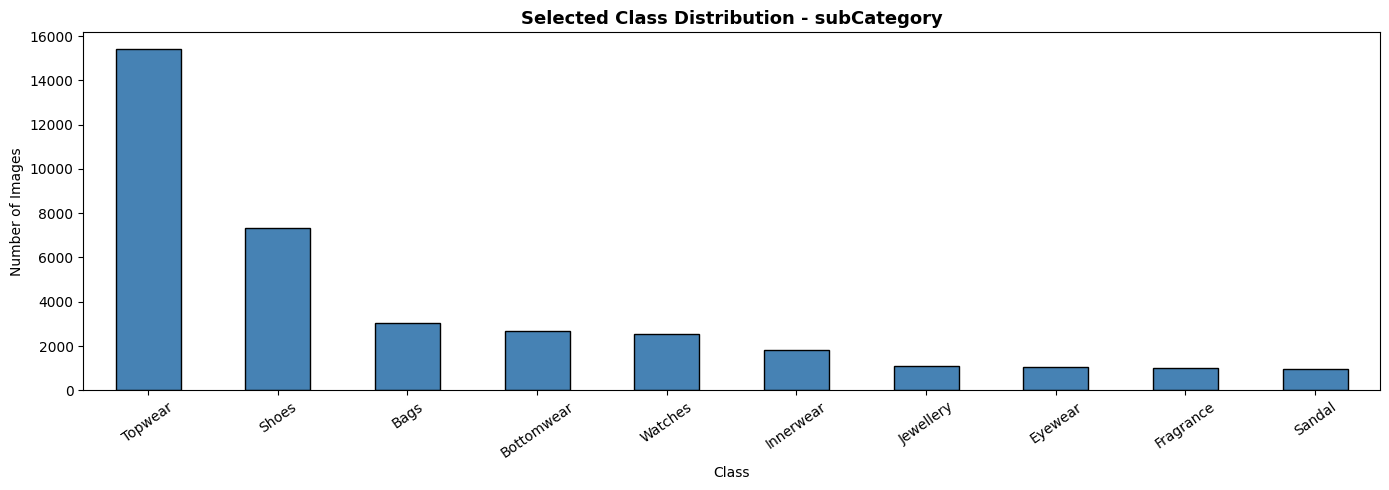

In [4]:
# Select the most frequent classes with enough examples. This creates a cleaner classification task.
class_counts = df[TARGET_COL].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES].head(TOP_N_CLASSES).index.tolist()
df = df[df[TARGET_COL].isin(valid_classes)].copy()

# Encode string labels into integer IDs.
class_to_idx = {cls: i for i, cls in enumerate(valid_classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
df['label'] = df[TARGET_COL].map(class_to_idx).astype('int32')
NUM_CLASSES = len(valid_classes)

print(f'Selected classes ({NUM_CLASSES}):')
for cls in valid_classes:
    print(f'  {cls:25s} {class_counts[cls]:5d}')
print(f'Filtered dataset size: {len(df):,}')

# Save class distribution figure.
fig, ax = plt.subplots(figsize=(14, 5))
df[TARGET_COL].value_counts().loc[valid_classes].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Selected Class Distribution - {TARGET_COL}', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_class_distribution.png', dpi=150)
plt.show()


## 5. Train / Validation / Test Split


In [5]:
# Stratified split keeps class proportions similar in train, validation, and test sets.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

print(f'Train/Val/Test: {len(train_df):,}/{len(val_df):,}/{len(test_df):,}')

# Confirm there is no image leakage between splits.
train_ids = set(train_df['id'].astype(str))
val_ids = set(val_df['id'].astype(str))
test_ids = set(test_df['id'].astype(str))
print('Train/Val overlap:', len(train_ids & val_ids))
print('Train/Test overlap:', len(train_ids & test_ids))
print('Val/Test overlap:', len(val_ids & test_ids))

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    counts = split['label'].value_counts().sort_index()
    print(f'\n{split_name.upper()} distribution')
    print(pd.DataFrame({
        'label': counts.index,
        'class': [idx_to_class[i] for i in counts.index],
        'count': counts.values,
        'pct': np.round(100 * counts.values / len(split), 2)
    }).to_string(index=False))

majority_label = train_df['label'].value_counts().idxmax()
print(f'\nRandom baseline: {1 / NUM_CLASSES:.4f}')
print(f"Majority validation baseline: {np.mean(val_df['label'].values == majority_label):.4f} ({idx_to_class[majority_label]})")


Train/Val/Test: 25,875/5,545/5,545
Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0

TRAIN distribution
 label      class  count   pct
     0    Topwear  10778 41.65
     1      Shoes   5140 19.86
     2       Bags   2139  8.27
     3 Bottomwear   1885  7.29
     4    Watches   1779  6.88
     5  Innerwear   1266  4.89
     6  Jewellery    755  2.92
     7    Eyewear    751  2.90
     8  Fragrance    708  2.74
     9     Sandal    674  2.60

VAL distribution
 label      class  count   pct
     0    Topwear   2310 41.66
     1      Shoes   1102 19.87
     2       Bags    458  8.26
     3 Bottomwear    404  7.29
     4    Watches    382  6.89
     5  Innerwear    271  4.89
     6  Jewellery    162  2.92
     7    Eyewear    161  2.90
     8  Fragrance    151  2.72
     9     Sandal    144  2.60

TEST distribution
 label      class  count   pct
     0    Topwear   2310 41.66
     1      Shoes   1101 19.86
     2       Bags    458  8.26
     3 Bottomwear    404  7.29
     4  

## 6. Image Resizing, Normalization, and tf.data Pipelines


I0000 00:00:1782678772.657215      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


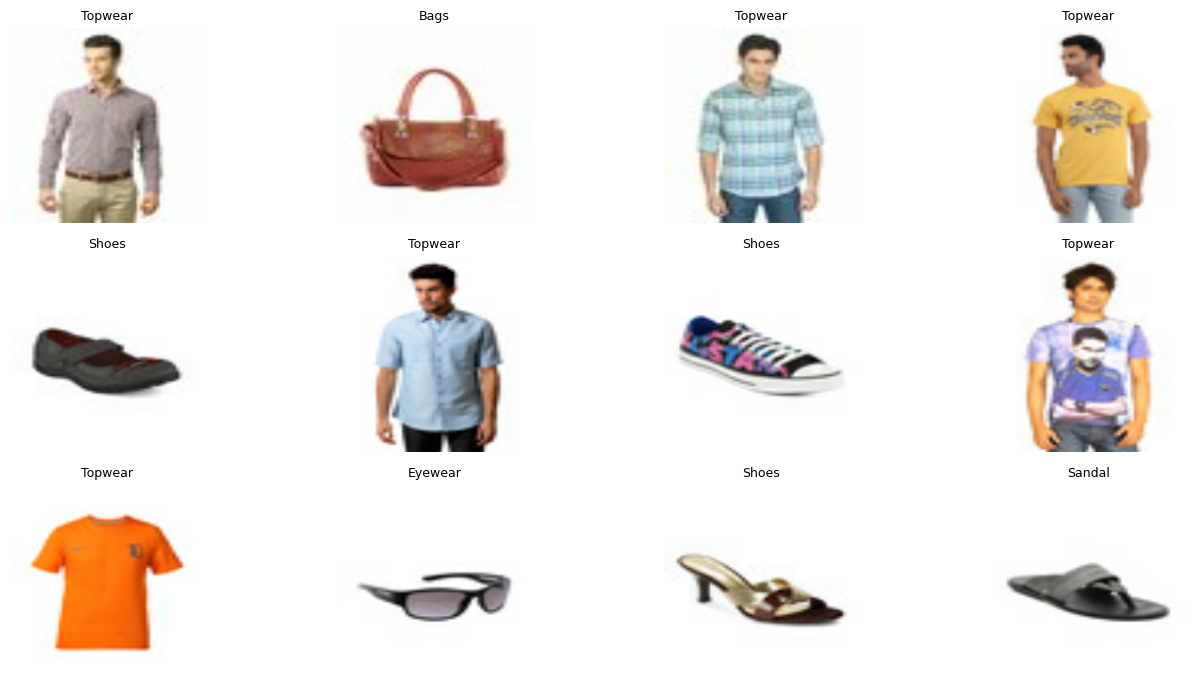

In [6]:
def decode_resize_normalize(path, label, one_hot=True):
    """Read an image, resize it, normalize pixels to [0, 1], and encode the label."""
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE, method='bilinear')
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.int32)
    if one_hot:
        label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def sample_beta_distribution(size, alpha):
    gamma_1 = tf.random.gamma(shape=[size], alpha=alpha)
    gamma_2 = tf.random.gamma(shape=[size], alpha=alpha)
    return gamma_1 / (gamma_1 + gamma_2)

def mixup_batch(images, labels):
    """MixUp combines pairs of images and labels to reduce overfitting."""
    batch_size = tf.shape(images)[0]
    lam = sample_beta_distribution(batch_size, MIXUP_ALPHA)
    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])
    indices = tf.random.shuffle(tf.range(batch_size))
    mixed_images = images * lam_x + tf.gather(images, indices) * (1.0 - lam_x)
    mixed_labels = labels * lam_y + tf.gather(labels, indices) * (1.0 - lam_y)
    return mixed_images, mixed_labels

def make_dataset(dataframe, training=False, mixup=False, one_hot=True):
    paths = dataframe['image_path'].values
    labels = dataframe['label'].values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: decode_resize_normalize(p, y, one_hot=one_hot), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training and mixup:
        ds = ds.map(mixup_batch, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, training=True, mixup=True, one_hot=True)
train_plain_ds = make_dataset(train_df, training=True, mixup=False, one_hot=True)
val_ds = make_dataset(val_df, training=False, mixup=False, one_hot=True)
test_ds = make_dataset(test_df, training=False, mixup=False, one_hot=True)

# Visual sanity check: verify images and labels match.
images, labels = next(iter(train_plain_ds))
plt.figure(figsize=(14, 7))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(idx_to_class[int(tf.argmax(labels[i]))], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_label_sanity_check.png', dpi=150)
plt.show()


## 7. Data Augmentation


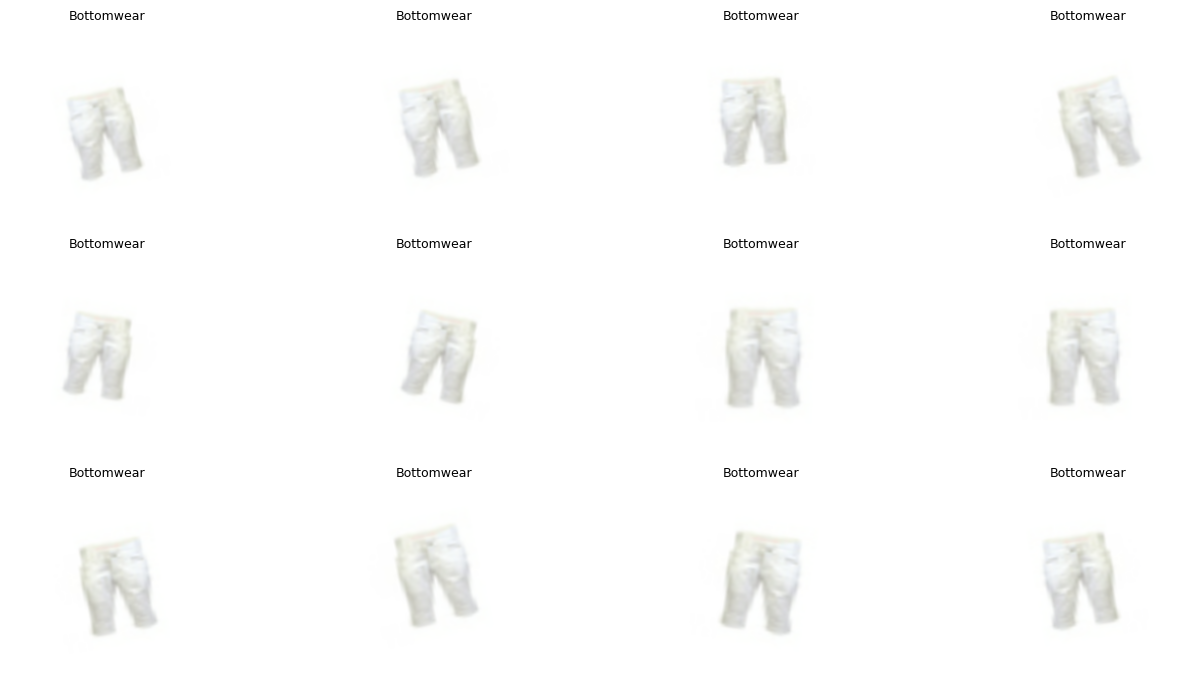

In [7]:
# These augmentation layers are used inside the custom CNN model.
# They run only during training and are disabled during validation/testing.
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
    layers.RandomTranslation(0.04, 0.04),
], name='data_augmentation')

# Save augmentation preview.
# Mixed precision can make augmentation output float16. Matplotlib may fail while saving
# float16 images, so cast preview images back to float32 before imshow/savefig.
plt.close('all')
preview_images, preview_labels = next(iter(train_plain_ds))
fig = plt.figure(figsize=(14, 7))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    aug_img = data_augmentation(preview_images[:1], training=True)[0]
    aug_img = tf.cast(tf.clip_by_value(aug_img, 0.0, 1.0), tf.float32).numpy()
    plt.imshow(aug_img)
    plt.title(idx_to_class[int(tf.argmax(preview_labels[0]))], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_augmentation_preview.png', dpi=150)
plt.show()
plt.close(fig)


## 8. Custom CNN Model Development


In [8]:
def se_block(x, ratio=8, name='se'):
    """Squeeze-and-excitation block helps the CNN learn useful channel weights."""
    channels = int(x.shape[-1])
    se = layers.GlobalAveragePooling2D(name=f'{name}_gap')(x)
    se = layers.Reshape((1, 1, channels), name=f'{name}_reshape')(se)
    se = layers.Dense(max(channels // ratio, 16), activation='relu', name=f'{name}_reduce')(se)
    se = layers.Dense(channels, activation='sigmoid', name=f'{name}_expand')(se)
    return layers.Multiply(name=f'{name}_scale')([x, se])

def conv_bn_act(x, filters, kernel_size=3, stride=1, name='conv'):
    x = layers.Conv2D(
        filters, kernel_size, strides=stride, padding='same', use_bias=False,
        kernel_initializer='he_normal', kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        name=f'{name}_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    return layers.Activation('swish', name=f'{name}_swish')(x)

def residual_se_block(x, filters, stride=1, dropout=0.0, name='block'):
    """Residual block with squeeze-and-excitation for stronger custom CNN learning."""
    shortcut = x
    if stride != 1 or int(x.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=stride, padding='same', use_bias=False,
            kernel_initializer='he_normal', kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
            name=f'{name}_shortcut_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    x = conv_bn_act(x, filters, 3, stride=stride, name=f'{name}_conv1')
    x = layers.Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_initializer='he_normal', kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY),
        name=f'{name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    x = se_block(x, ratio=8, name=f'{name}_se')
    x = layers.Add(name=f'{name}_add')([x, shortcut])
    x = layers.Activation('swish', name=f'{name}_out')(x)
    if dropout > 0:
        x = layers.SpatialDropout2D(dropout, name=f'{name}_spatial_dropout')(x)
    return x

def build_custom_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape, name='image')
    x = data_augmentation(inputs)

    x = conv_bn_act(x, 48, 3, stride=1, name='stem1')
    x = conv_bn_act(x, 64, 3, stride=2, name='stem2')

    x = residual_se_block(x, 64, stride=1, dropout=0.00, name='stage1_block1')
    x = residual_se_block(x, 64, stride=1, dropout=0.00, name='stage1_block2')

    x = residual_se_block(x, 128, stride=2, dropout=0.03, name='stage2_block1')
    x = residual_se_block(x, 128, stride=1, dropout=0.03, name='stage2_block2')

    x = residual_se_block(x, 256, stride=2, dropout=0.06, name='stage3_block1')
    x = residual_se_block(x, 256, stride=1, dropout=0.06, name='stage3_block2')
    x = residual_se_block(x, 256, stride=1, dropout=0.06, name='stage3_block3')

    x = residual_se_block(x, 384, stride=2, dropout=0.08, name='stage4_block1')
    x = residual_se_block(x, 384, stride=1, dropout=0.08, name='stage4_block2')

    x = residual_se_block(x, 512, stride=2, dropout=0.10, name='stage5_block1')
    x = residual_se_block(x, 512, stride=1, dropout=0.10, name='stage5_block2')

    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.Dropout(0.35, name='head_dropout')(x)
    x = layers.Dense(
        512, use_bias=False, kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY), name='head_dense')(x)
    x = layers.BatchNormalization(name='head_bn')(x)
    x = layers.Activation('swish', name='head_swish')(x)
    x = layers.Dropout(0.35, name='head_dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)
    return keras.Model(inputs, outputs, name='CustomResNetSE_CNN')

custom_model = build_custom_cnn((*IMG_SIZE, 3), NUM_CLASSES)
custom_model.summary()


Model: "CustomResNetSE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 192, 192,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 192, 192,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_conv (Conv2D) │ (None, 192, 192,  │      1,296 │ data_augmentatio… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_bn            │ (None, 192, 192,  │        192 │ stem1_conv[0][0]  │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem1_swish         │ (None, 192, 192,  │          0 │ stem1_bn[0][0]    │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_conv (Conv2D) │ (None, 96, 96,    │     27,648 │ stem1_swish[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_bn            │ (None, 96, 96,    │        256 │ stem2_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem2_swish         │ (None, 96, 96,    │          0 │ stem2_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv… │ (None, 96, 96,    │     36,864 │ stem2_swish[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv… │ (None, 96, 96,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv… │ (None, 96, 96,    │          0 │ stage1_block1_co… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 96, 96,    │     36,864 │ stage1_block1_co… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 96, 96,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_se_g… │ (None, 64)        │          0 │ stage1_block1_bn… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_se_r… │ (None, 1, 1, 64)  │          0 │ stage1_block1_se… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_se_r… │ (None, 1, 1, 16)  │      1,040 │ stage1_block1_se… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_se_e… │ (None, 1, 1, 64)  │      1,088 │ stage1_block1_se

 Total params: 18,553,818 (70.78 MB)

 Trainable params: 18,538,234 (70.72 MB)

 Non-trainable params: 15,584 (60.88 KB)

## 9. Model Training


In [9]:
def make_optimizer(lr_schedule):
    """Use AdamW if available; otherwise fall back to Adam."""
    try:
        return keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=WEIGHT_DECAY,
            clipnorm=1.0,
            use_ema=True,
            ema_momentum=0.99
        )
    except TypeError:
        try:
            return keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, clipnorm=1.0)
        except AttributeError:
            return keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)

steps_per_epoch = int(np.ceil(len(train_df) / BATCH_SIZE))
decay_steps = steps_per_epoch * CUSTOM_EPOCHS
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=decay_steps,
    alpha=0.02
)

custom_model.compile(
    optimizer=make_optimizer(lr_schedule),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=[
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')
    ]
)

custom_callbacks = [
    ModelCheckpoint('best_custom_cnn.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', mode='max', patience=25, restore_best_weights=True, verbose=1),
    CSVLogger('custom_cnn_training_log.csv')
]

# Optional diagnostic: a custom CNN should memorize a tiny subset. If not, check labels/preprocessing first.
if RUN_SMALL_OVERFIT_TEST:
    small_df = train_df.groupby('label', group_keys=False).head(16).copy()
    small_ds = make_dataset(small_df, training=True, mixup=False, one_hot=True)
    small_model = build_custom_cnn((*IMG_SIZE, 3), NUM_CLASSES)
    small_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
        metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
    )
    print(f'Running small-batch overfit test on {len(small_df)} images...')
    small_model.fit(small_ds, epochs=35, verbose=1)
    small_loss, small_acc = small_model.evaluate(small_ds, verbose=0)
    print(f'Small-batch overfit accuracy: {small_acc:.4f}')
    if small_acc < 0.90:
        print('WARNING: Low small-batch accuracy suggests a data, label, or preprocessing issue.')

history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CUSTOM_EPOCHS,
    callbacks=custom_callbacks,
    verbose=1
)


Running small-batch overfit test on 160 images...
Epoch 1/35


E0000 00:00:1782678809.435613      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CustomResNetSE_CNN_1/stage2_block1_spatial_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1782678813.260700      63 cuda_dnn.cc:529] Loaded cuDNN version 91002


5/5 ━━━━━━━━━━━━━━━━━━━━ 55s 315ms/step - accuracy: 0.1312 - loss: 4.1859
Epoch 2/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.1000 - loss: 4.0913
Epoch 3/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.0875 - loss: 3.9813
Epoch 4/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.1625 - loss: 4.0333
Epoch 5/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.1937 - loss: 3.9582
Epoch 6/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - accuracy: 0.1813 - loss: 3.9882
Epoch 7/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.2125 - loss: 3.8549
Epoch 8/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.2438 - loss: 3.8631
Epoch 9/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - accuracy: 0.2937 - loss: 3.6460
Epoch 10/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.3063 - loss: 3.6598
Epoch 11/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - accuracy: 0.2375 - loss: 3.5411
Epoch 12/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.3375 - loss: 3.3376

E0000 00:00:1782678936.854784      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CustomResNetSE_CNN_1/stage2_block1_spatial_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.5394 - loss: 2.8746 - top3_accuracy: 0.7593
Epoch 1: val_accuracy improved from None to 0.84563, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 364s 390ms/step - accuracy: 0.6606 - loss: 2.3153 - top3_accuracy: 0.8550 - val_accuracy: 0.8456 - val_loss: 1.4483 - val_top3_accuracy: 0.9385
Epoch 2/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7947 - loss: 1.5641 - top3_accuracy: 0.9377
Epoch 2: val_accuracy improved from 0.84563 to 0.87538, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 294s 363ms/step - accuracy: 0.8065 - loss: 1.4866 - top3_accuracy: 0.9413 - val_accuracy: 0.8754 - val_loss: 1.1551 - val_top3_accuracy: 0.9647
Epoch 3/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.8380 - loss: 1.2969 - top3_accuracy: 0.9560
Epoch 3: val_accuracy improved

## 10. Accuracy and Loss Curves


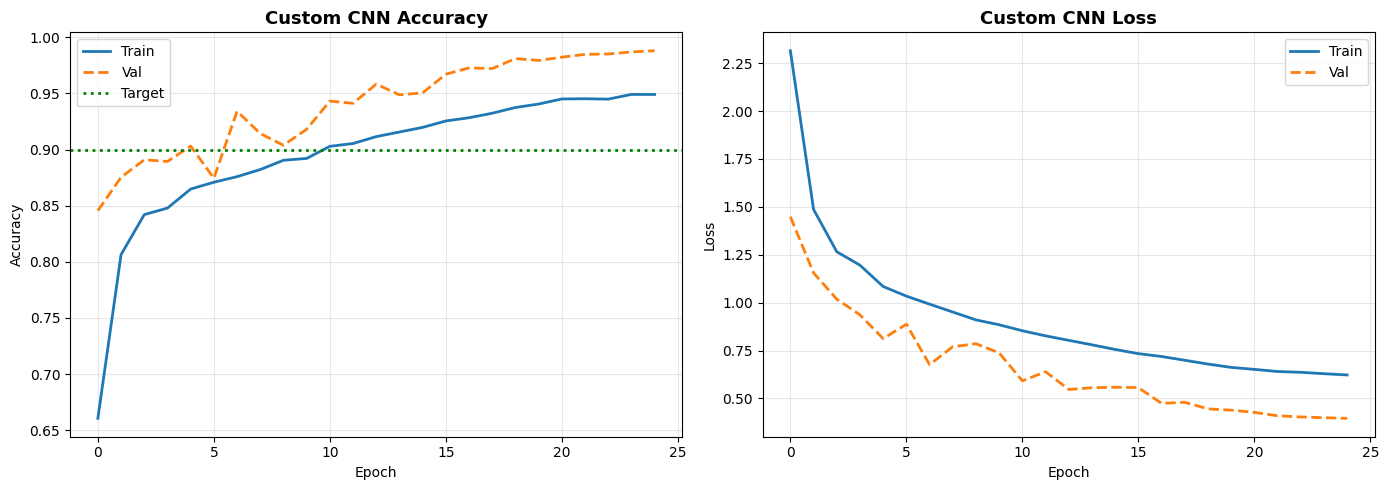

In [10]:
def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val', linewidth=2, linestyle='--')
    ax1.axhline(TARGET_ACCURACY, color='green', linewidth=2, linestyle=':', label='Target')
    ax1.set_title(f'{title} Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'], label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val', linewidth=2, linestyle='--')
    ax2.set_title(f'{title} Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_history(history_custom, 'Custom CNN', FIGURES_DIR / '04_custom_cnn_accuracy_loss.png')


## 11. Model Evaluation, Confusion Matrix, and Classification Report


Custom CNN Test Accuracy: 0.9841
Custom CNN Weighted F1:   0.9841

Custom CNN Classification Report:
              precision    recall  f1-score   support

     Topwear     0.9897    0.9965    0.9931      2310
       Shoes     0.9792    0.9827    0.9810      1101
        Bags     0.9890    0.9825    0.9858       458
  Bottomwear     0.9850    0.9777    0.9814       404
     Watches     0.9974    0.9948    0.9961       381
   Innerwear     0.9808    0.9410    0.9605       271
   Jewellery     0.9815    0.9815    0.9815       162
     Eyewear     1.0000    1.0000    1.0000       161
   Fragrance     0.9869    0.9934    0.9902       152
      Sandal     0.8662    0.8483    0.8571       145

    accuracy                         0.9841      5545
   macro avg     0.9756    0.9698    0.9726      5545
weighted avg     0.9841    0.9841    0.9841      5545



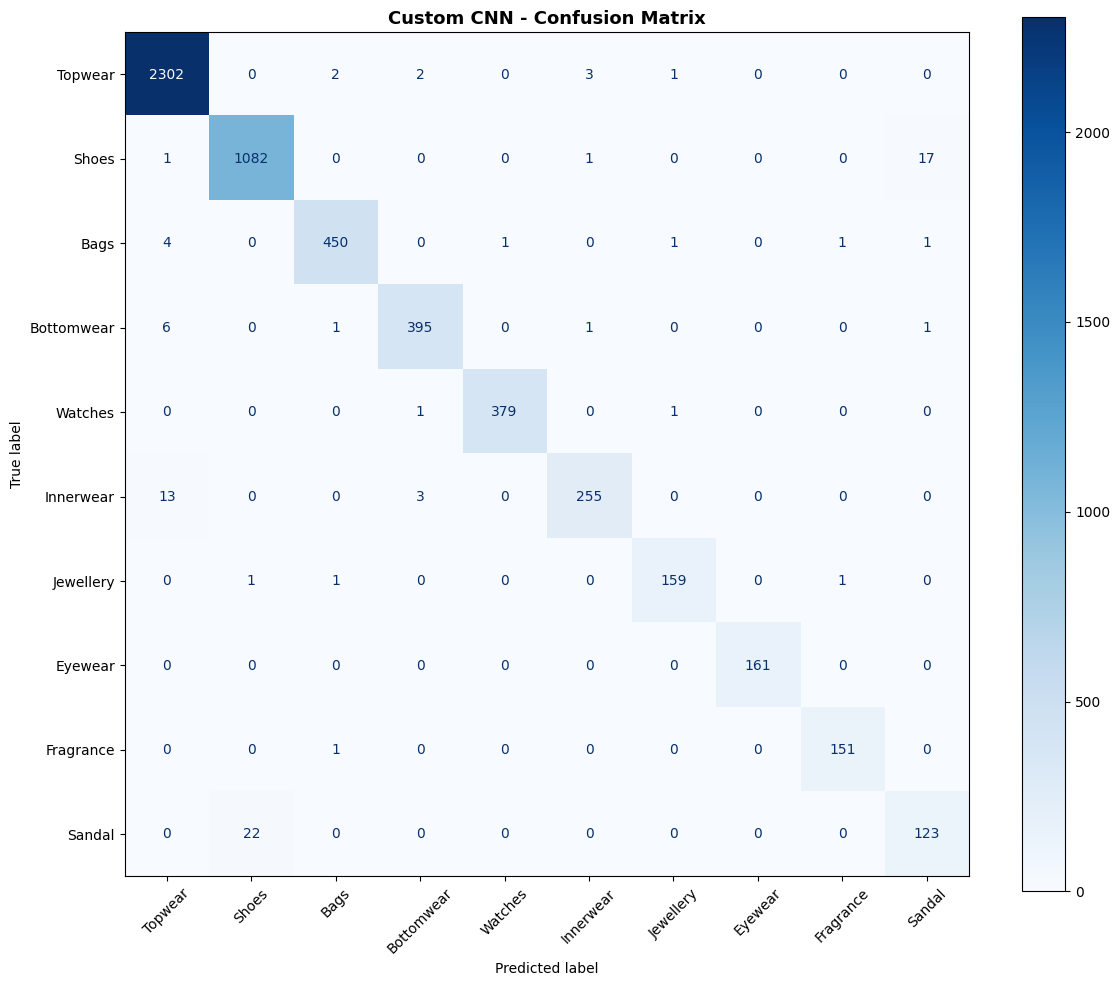

In [11]:
def collect_true_labels(dataset):
    labels = []
    for _, y in dataset:
        labels.append(tf.argmax(y, axis=1).numpy())
    return np.concatenate(labels)

def predict_with_tta(model, dataset):
    """Average normal and horizontally flipped predictions."""
    pred_normal = model.predict(dataset, verbose=0)
    if not RUN_TEST_TIME_AUGMENTATION:
        return pred_normal
    flipped_ds = dataset.map(lambda x, y: (tf.image.flip_left_right(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    pred_flip = model.predict(flipped_ds, verbose=0)
    return (pred_normal + pred_flip) / 2.0

y_test_true = collect_true_labels(test_ds)
custom_test_proba = predict_with_tta(custom_model, test_ds)
custom_test_pred = np.argmax(custom_test_proba, axis=1)

class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)]
custom_acc = accuracy_score(y_test_true, custom_test_pred)
custom_f1 = f1_score(y_test_true, custom_test_pred, average='weighted')
print(f'Custom CNN Test Accuracy: {custom_acc:.4f}')
print(f'Custom CNN Weighted F1:   {custom_f1:.4f}')
print('\nCustom CNN Classification Report:')
print(classification_report(y_test_true, custom_test_pred, target_names=class_labels, digits=4))

cm_custom = confusion_matrix(y_test_true, custom_test_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_custom, display_labels=class_labels).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Custom CNN - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_custom_cnn_confusion_matrix.png', dpi=150)
plt.show()


## 12. Transfer Learning Model for Comparison


In [12]:
def build_mobilenetv2_model(num_classes):
    """MobileNetV2 comparison model using ImageNet transfer learning."""
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name='image')
    x = data_augmentation(inputs)
    # Dataset images are normalized to [0, 1]. MobileNetV2 expects preprocess_input on [0, 255].
    x = layers.Lambda(lambda img: mobilenet_preprocess(img * 255.0), name='mobilenet_preprocess')(x)
    base = MobileNetV2(include_top=False, weights='imagenet', input_tensor=x, pooling=None)
    base.trainable = False
    x = layers.GlobalAveragePooling2D(name='avg_pool')(base.output)
    x = layers.Dropout(0.30, name='tl_dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)
    model = keras.Model(inputs, outputs, name='MobileNetV2_TransferLearning')
    return model, base

tl_model, tl_base = build_mobilenetv2_model(NUM_CLASSES)
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
)

tl_callbacks_head = [
    ModelCheckpoint('best_mobilenetv2_head.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True, verbose=1),
    CSVLogger('mobilenetv2_head_training_log.csv')
]

print('Phase 1: train transfer-learning classification head')
history_tl_head = tl_model.fit(
    train_plain_ds,
    validation_data=val_ds,
    epochs=TL_HEAD_EPOCHS,
    callbacks=tl_callbacks_head,
    verbose=1
)

# Fine-tune top layers while keeping BatchNorm frozen for stable validation.
tl_base.trainable = True
fine_tune_at = int(len(tl_base.layers) * 0.70)
for layer in tl_base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in tl_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
)

tl_callbacks_fine = [
    ModelCheckpoint('best_mobilenetv2_finetuned.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', mode='max', patience=7, restore_best_weights=True, verbose=1),
    CSVLogger('mobilenetv2_finetune_training_log.csv')
]

print('Phase 2: fine-tune transfer-learning model')
history_tl_fine = tl_model.fit(
    train_plain_ds,
    validation_data=val_ds,
    epochs=TL_FINE_EPOCHS,
    callbacks=tl_callbacks_fine,
    verbose=1
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: train transfer-learning classification head
Epoch 1/8
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8560 - loss: 0.5855
Epoch 1: val_accuracy improved from None to 0.97223, saving model to best_mobilenetv2_head.keras

Epoch 1: finished saving model to best_mobilenetv2_head.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 75s 74ms/step - accuracy: 0.9262 - loss: 0.3722 - val_accuracy: 0.9722 - val_loss: 0.2352
Epoch 2/8
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9604 - loss: 0.2687
Epoch 2: val_accuracy improved from 0.97223 to 0.97367, saving model to best_mobilenetv2_head.keras

Epoch 2: finished saving model to best_mobilenetv2_head.keras
809/809 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9622 - loss: 0.2653 - val_accuracy: 0.9737 - val_loss: 0.2251
Epoch 3/8
809/809 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9673 - loss: 0.2526
Epoch 3: val_accuracy improved from 0.97367 to 0.97764, saving model to best_mo

## 13. Transfer Learning Curves and Evaluation


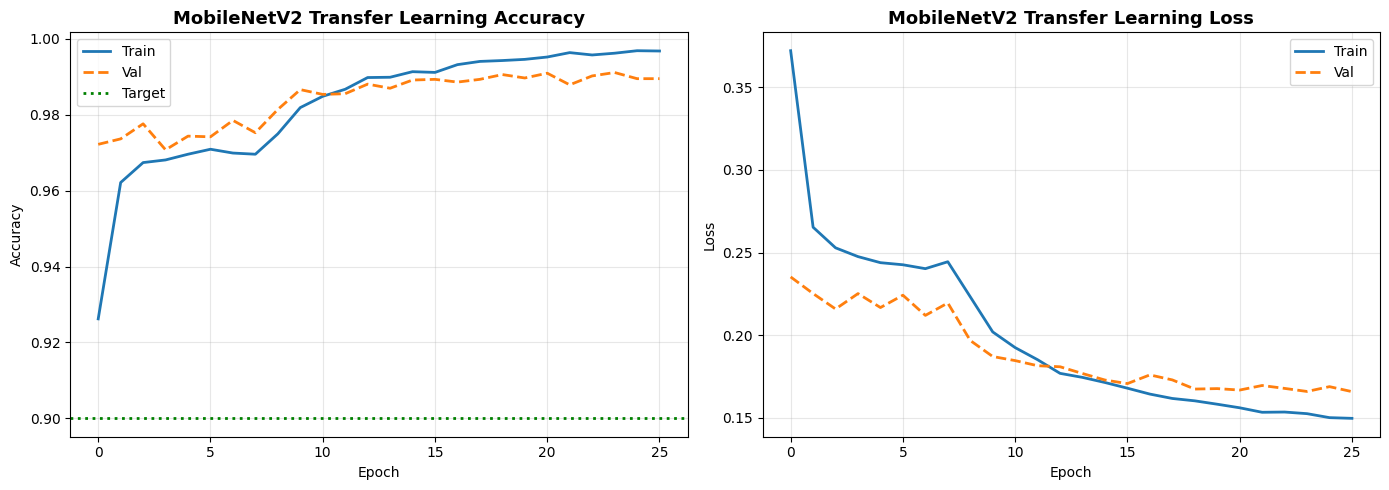

MobileNetV2 Test Accuracy: 0.9879
MobileNetV2 Weighted F1:   0.9877

MobileNetV2 Classification Report:
              precision    recall  f1-score   support

     Topwear     0.9948    0.9983    0.9965      2310
       Shoes     0.9750    0.9909    0.9829      1101
        Bags     0.9891    0.9869    0.9880       458
  Bottomwear     0.9827    0.9851    0.9839       404
     Watches     0.9974    0.9974    0.9974       381
   Innerwear     0.9887    0.9668    0.9776       271
   Jewellery     0.9937    0.9753    0.9844       162
     Eyewear     1.0000    1.0000    1.0000       161
   Fragrance     0.9869    0.9934    0.9902       152
      Sandal     0.9370    0.8207    0.8750       145

    accuracy                         0.9879      5545
   macro avg     0.9845    0.9715    0.9776      5545
weighted avg     0.9878    0.9879    0.9877      5545



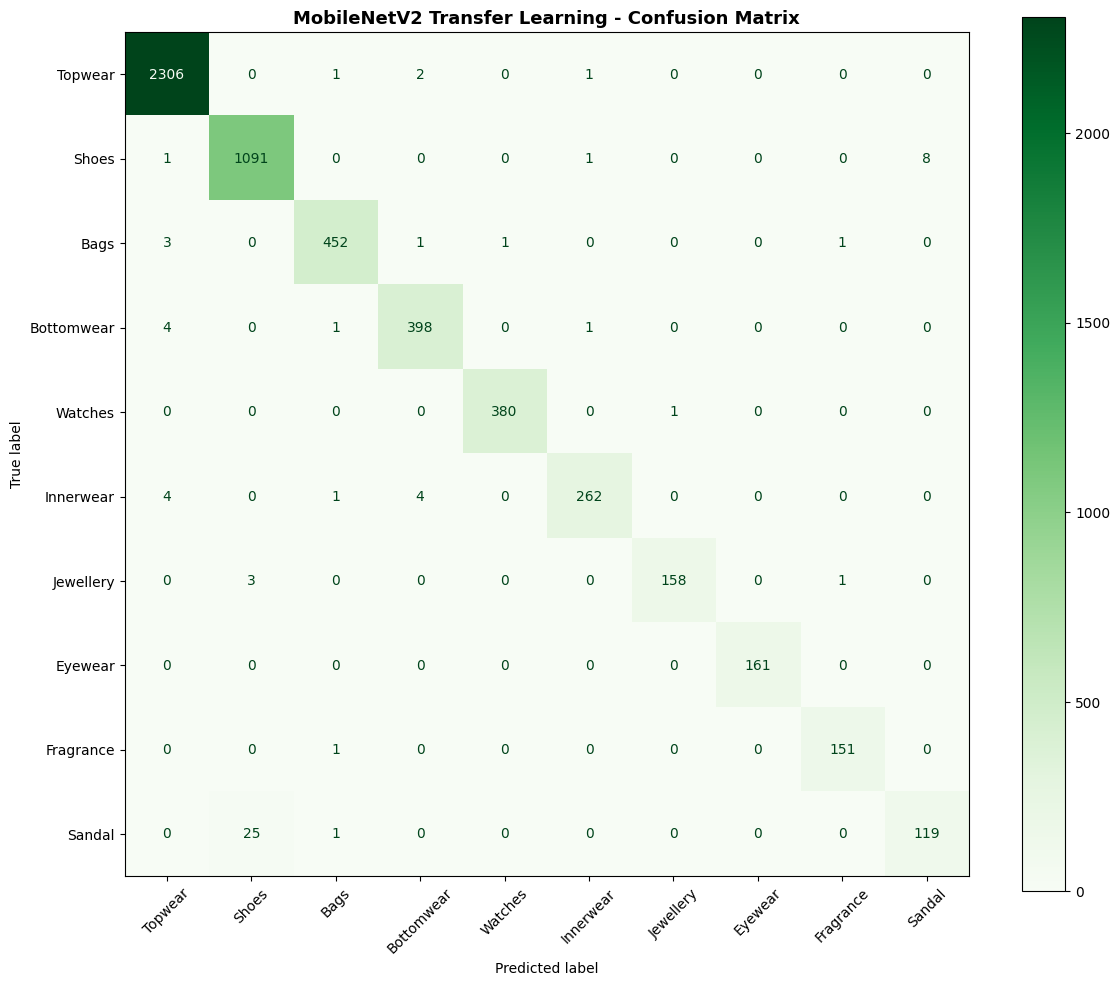

In [13]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        if key in h2.history:
            merged[key] = h1.history[key] + h2.history[key]
    return type('HistoryLike', (), {'history': merged})()

history_tl = merge_histories(history_tl_head, history_tl_fine)
plot_history(history_tl, 'MobileNetV2 Transfer Learning', FIGURES_DIR / '06_mobilenetv2_accuracy_loss.png')

tl_test_proba = predict_with_tta(tl_model, test_ds)
tl_test_pred = np.argmax(tl_test_proba, axis=1)
tl_acc = accuracy_score(y_test_true, tl_test_pred)
tl_f1 = f1_score(y_test_true, tl_test_pred, average='weighted')

print(f'MobileNetV2 Test Accuracy: {tl_acc:.4f}')
print(f'MobileNetV2 Weighted F1:   {tl_f1:.4f}')
print('\nMobileNetV2 Classification Report:')
print(classification_report(y_test_true, tl_test_pred, target_names=class_labels, digits=4))

cm_tl = confusion_matrix(y_test_true, tl_test_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_tl, display_labels=class_labels).plot(ax=ax, cmap='Greens', xticks_rotation=45)
ax.set_title('MobileNetV2 Transfer Learning - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_mobilenetv2_confusion_matrix.png', dpi=150)
plt.show()


## 14. Model Comparison Table


         Metric  Custom CNN  MobileNetV2 TL
       Accuracy      0.9841          0.9879
Macro Precision      0.9756          0.9845
   Macro Recall      0.9698          0.9715
       Macro F1      0.9726          0.9776
    Weighted F1      0.9841          0.9877


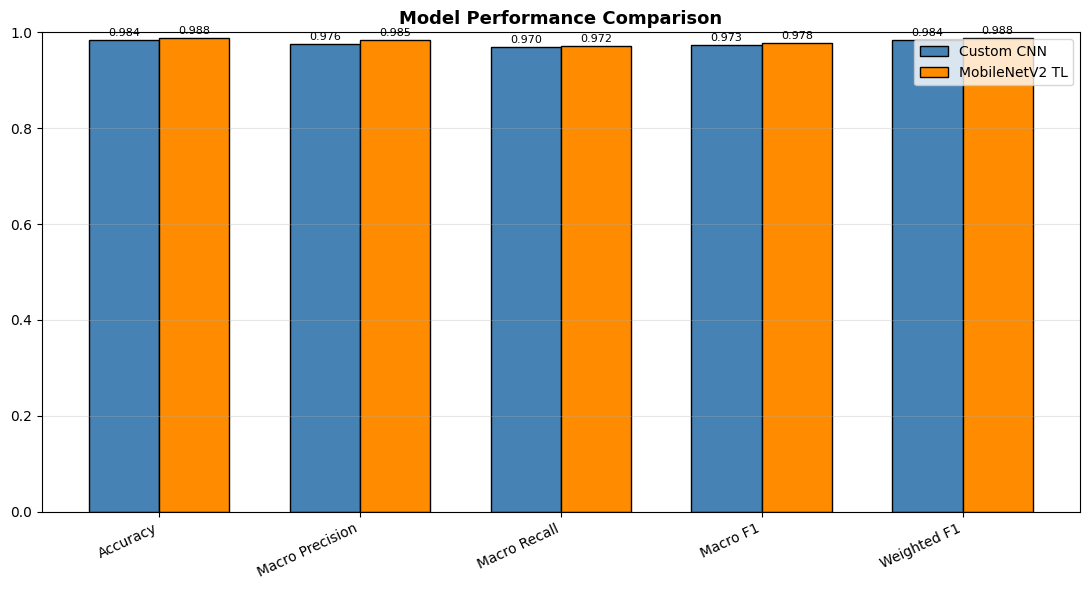

In [14]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

custom_metrics = compute_metrics(y_test_true, custom_test_pred)
tl_metrics = compute_metrics(y_test_true, tl_test_pred)
comparison_df = pd.DataFrame({
    'Metric': list(custom_metrics.keys()),
    'Custom CNN': [round(v, 4) for v in custom_metrics.values()],
    'MobileNetV2 TL': [round(v, 4) for v in tl_metrics.values()],
})
print(comparison_df.to_string(index=False))
comparison_df.to_csv(FIGURES_DIR / '08_model_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison_df))
w = 0.35
b1 = ax.bar(x - w/2, comparison_df['Custom CNN'], w, label='Custom CNN', color='steelblue', edgecolor='black')
b2 = ax.bar(x + w/2, comparison_df['MobileNetV2 TL'], w, label='MobileNetV2 TL', color='darkorange', edgecolor='black')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'], rotation=25, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in [*b1, *b2]:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_model_comparison_chart.png', dpi=150)
plt.show()


## 15. ROC Curves


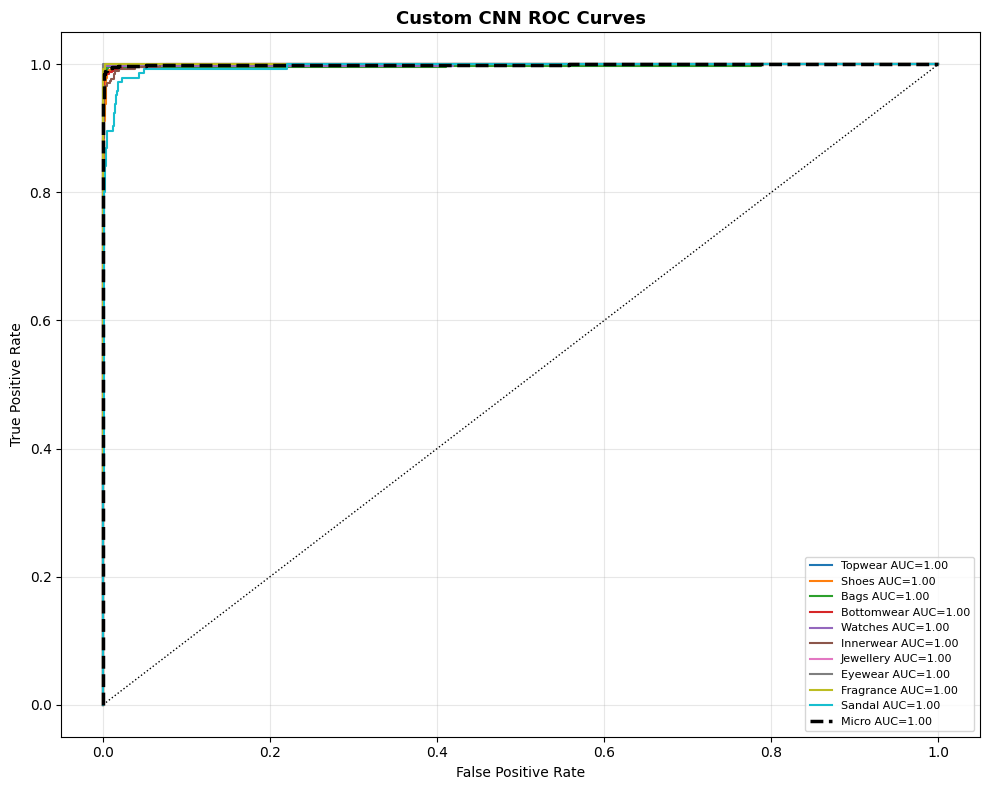

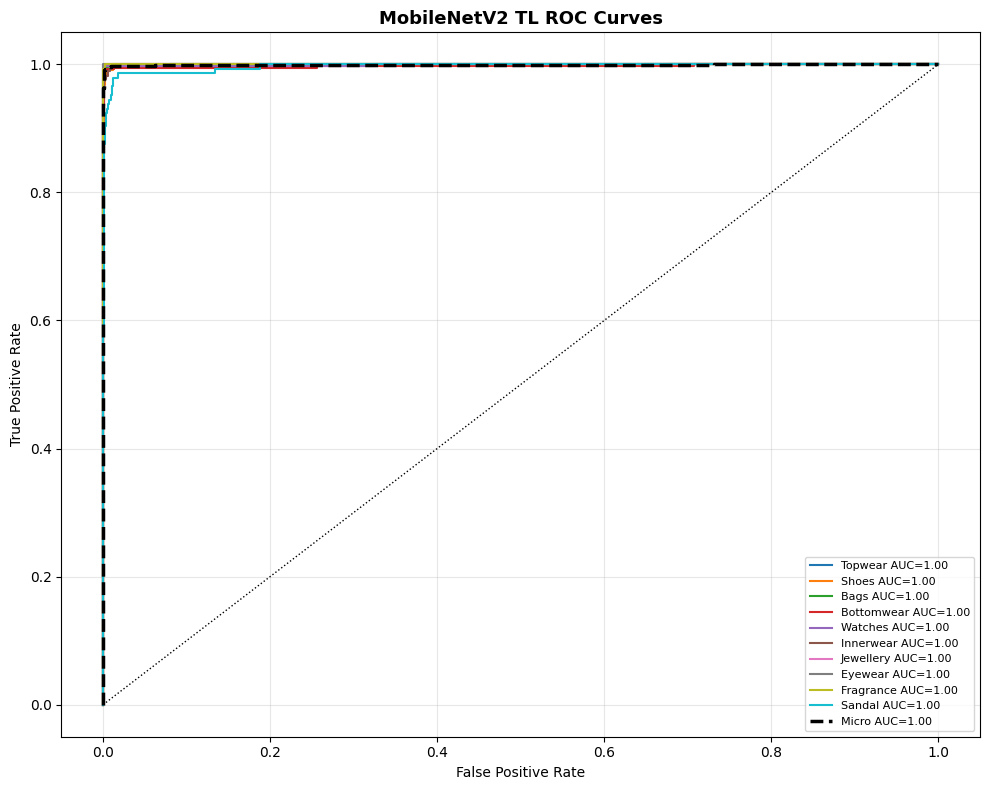

Custom CNN Micro-AUC: 0.9993
MobileNetV2 Micro-AUC: 0.9992


In [15]:
def plot_multiclass_roc(y_true, y_score, model_name, save_path):
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.cm.get_cmap('tab10', NUM_CLASSES)
    auc_values = {}
    for i, label in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_values[label] = roc_auc
        ax.plot(fpr, tpr, color=cmap(i), linewidth=1.5, label=f'{label} AUC={roc_auc:.2f}')
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    micro_auc = auc(fpr_micro, tpr_micro)
    ax.plot(fpr_micro, tpr_micro, 'k--', linewidth=2.5, label=f'Micro AUC={micro_auc:.2f}')
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1)
    ax.set_title(f'{model_name} ROC Curves', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    return micro_auc, auc_values

custom_micro_auc, custom_auc_values = plot_multiclass_roc(
    y_test_true, custom_test_proba, 'Custom CNN', FIGURES_DIR / '10_custom_cnn_roc_curves.png')
tl_micro_auc, tl_auc_values = plot_multiclass_roc(
    y_test_true, tl_test_proba, 'MobileNetV2 TL', FIGURES_DIR / '11_mobilenetv2_roc_curves.png')

print(f'Custom CNN Micro-AUC: {custom_micro_auc:.4f}')
print(f'MobileNetV2 Micro-AUC: {tl_micro_auc:.4f}')


## 16. Grad-CAM Visualization for Custom CNN


Loaded best_custom_cnn.keras for Grad-CAM.
Grad-CAM layer: stage5_block2_conv2


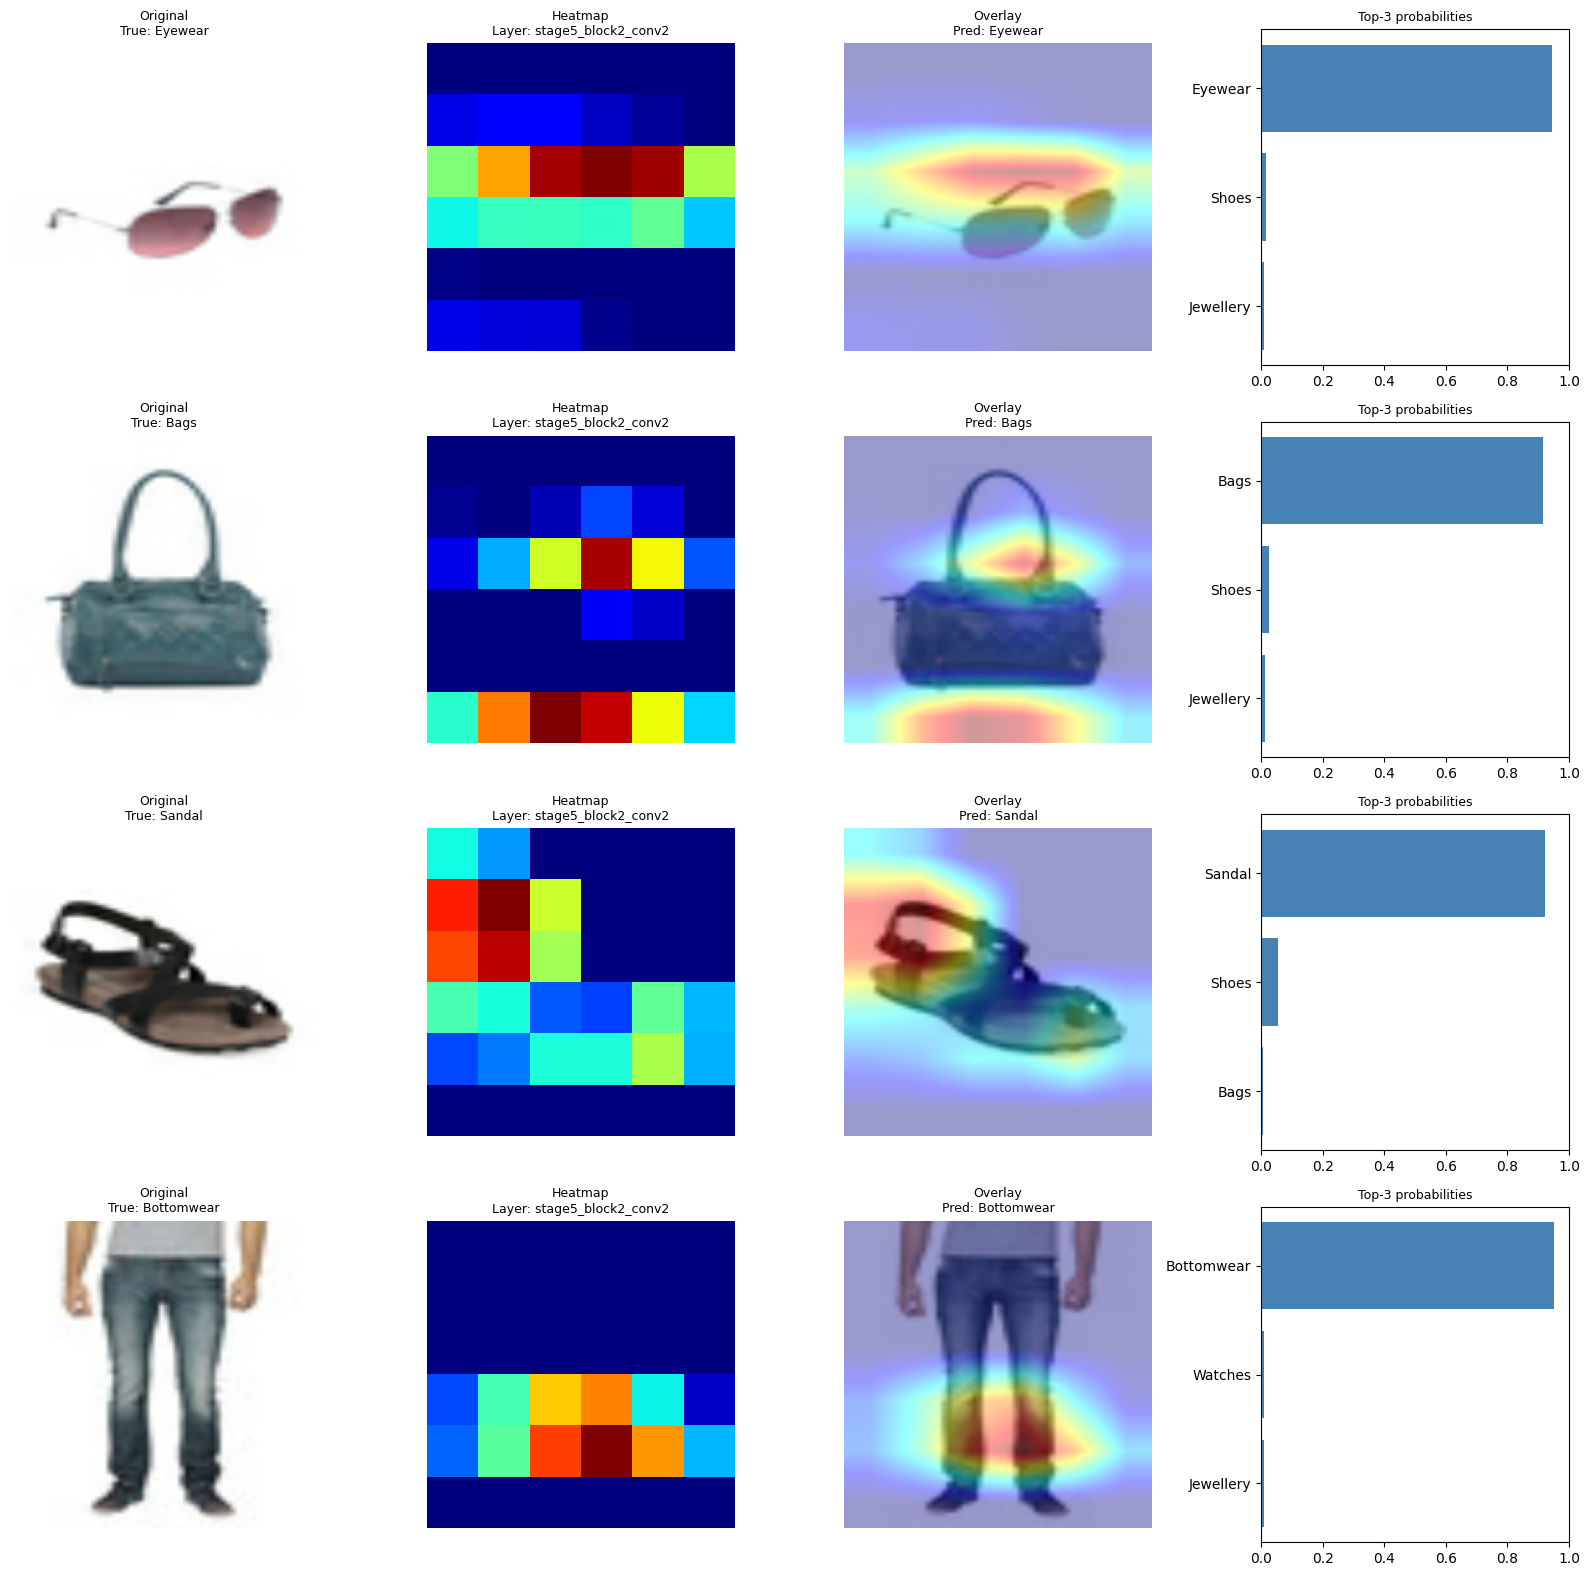

Grad-CAM figure saved to: /kaggle/working/figures/12_custom_cnn_gradcam.png


In [16]:
def find_last_conv_layer(model):
    """Return the name of the last Conv2D layer in a model, searching nested models too."""
    conv_layers = []
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            conv_layers.append(layer.name)
        elif isinstance(layer, keras.Model):
            for nested_layer in layer.layers:
                if isinstance(nested_layer, layers.Conv2D):
                    conv_layers.append(nested_layer.name)
    if not conv_layers:
        raise ValueError('No Conv2D layer found. Grad-CAM needs a convolution layer.')
    return conv_layers[-1]

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, pred_index=None):
    """Create a Grad-CAM heatmap for one image tensor of shape (1, H, W, 3)."""
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    # Ensure the model has been called before creating the gradient model.
    _ = model(tf.cast(img_array, tf.float32), training=False)

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(tf.cast(img_array, tf.float32), training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise ValueError('Gradients are None. Try a different convolution layer or make sure the model is trained/loaded.')

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy().astype('float32'), int(pred_index.numpy()), last_conv_layer_name

def overlay_gradcam(image, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on an image normalized to [0, 1]."""
    image = np.clip(image.astype('float32'), 0, 1)
    heatmap = np.clip(heatmap.astype('float32'), 0, 1)
    h = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    colored = cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    base = np.uint8(255 * image)
    return cv2.addWeighted(base, 1 - alpha, colored, alpha, 0)

# Choose a model for Grad-CAM. This works even after a runtime restart.
# Priority: best checkpoint -> final saved model -> in-memory custom_model.
gradcam_model = None
for model_path in ['best_custom_cnn.keras', 'custom_cnn_final.keras']:
    if Path(model_path).exists():
        try:
            gradcam_model = keras.models.load_model(model_path, compile=False)
            print(f'Loaded {model_path} for Grad-CAM.')
            break
        except Exception as exc:
            print(f'Could not load {model_path}: {exc}')

if gradcam_model is None and 'custom_model' in globals():
    gradcam_model = custom_model
    print('Using in-memory custom_model for Grad-CAM.')

if gradcam_model is None:
    raise NameError(
        "No custom CNN model is available for Grad-CAM. Run the custom CNN model-development/training cells first, "
        "or make sure best_custom_cnn.keras or custom_cnn_final.keras exists in the current notebook working directory."
    )

last_conv_layer = find_last_conv_layer(gradcam_model)
print(f'Grad-CAM layer: {last_conv_layer}')

example_images, example_labels = next(iter(test_ds))
n_examples = min(4, example_images.shape[0])
fig, axes = plt.subplots(n_examples, 4, figsize=(16, 4 * n_examples))
if n_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n_examples):
    image = tf.cast(example_images[row], tf.float32).numpy()
    true_idx = int(tf.argmax(example_labels[row]))
    img_tensor = tf.expand_dims(tf.cast(example_images[row], tf.float32), axis=0)

    try:
        heatmap, pred_idx, used_layer = make_gradcam_heatmap(img_tensor, gradcam_model, last_conv_layer)
        pred_probs = gradcam_model.predict(img_tensor, verbose=0)[0]
        overlay = overlay_gradcam(image, heatmap)

        axes[row, 0].imshow(np.clip(image, 0, 1))
        axes[row, 0].set_title(f'Original\nTrue: {idx_to_class[true_idx]}', fontsize=9)
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title(f'Heatmap\nLayer: {used_layer}', fontsize=9)
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'Overlay\nPred: {idx_to_class[pred_idx]}', fontsize=9)

        top3 = np.argsort(pred_probs)[::-1][:3]
        axes[row, 3].barh([idx_to_class[i] for i in top3[::-1]], pred_probs[top3[::-1]], color='steelblue')
        axes[row, 3].set_xlim(0, 1)
        axes[row, 3].set_title('Top-3 probabilities', fontsize=9)
    except Exception as exc:
        for col in range(4):
            axes[row, col].text(0.5, 0.5, f'Grad-CAM failed:\n{exc}', ha='center', va='center', wrap=True)

    for col in range(4):
        axes[row, col].axis('off') if col < 3 else None

plt.tight_layout()
gradcam_path = FIGURES_DIR / '12_custom_cnn_gradcam.png'
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grad-CAM figure saved to: {gradcam_path.resolve()}')


## 17. Error Analysis


Custom CNN misclassified: 88/5545 (1.6%)

Top confusion pairs for Custom CNN:
Sandal                    -> Shoes                       22
Shoes                     -> Sandal                      17
Innerwear                 -> Topwear                     13
Bottomwear                -> Topwear                      6
Bags                      -> Topwear                      4
Topwear                   -> Innerwear                    3
Innerwear                 -> Bottomwear                   3
Topwear                   -> Bottomwear                   2
Topwear                   -> Bags                         2
Fragrance                 -> Bags                         1


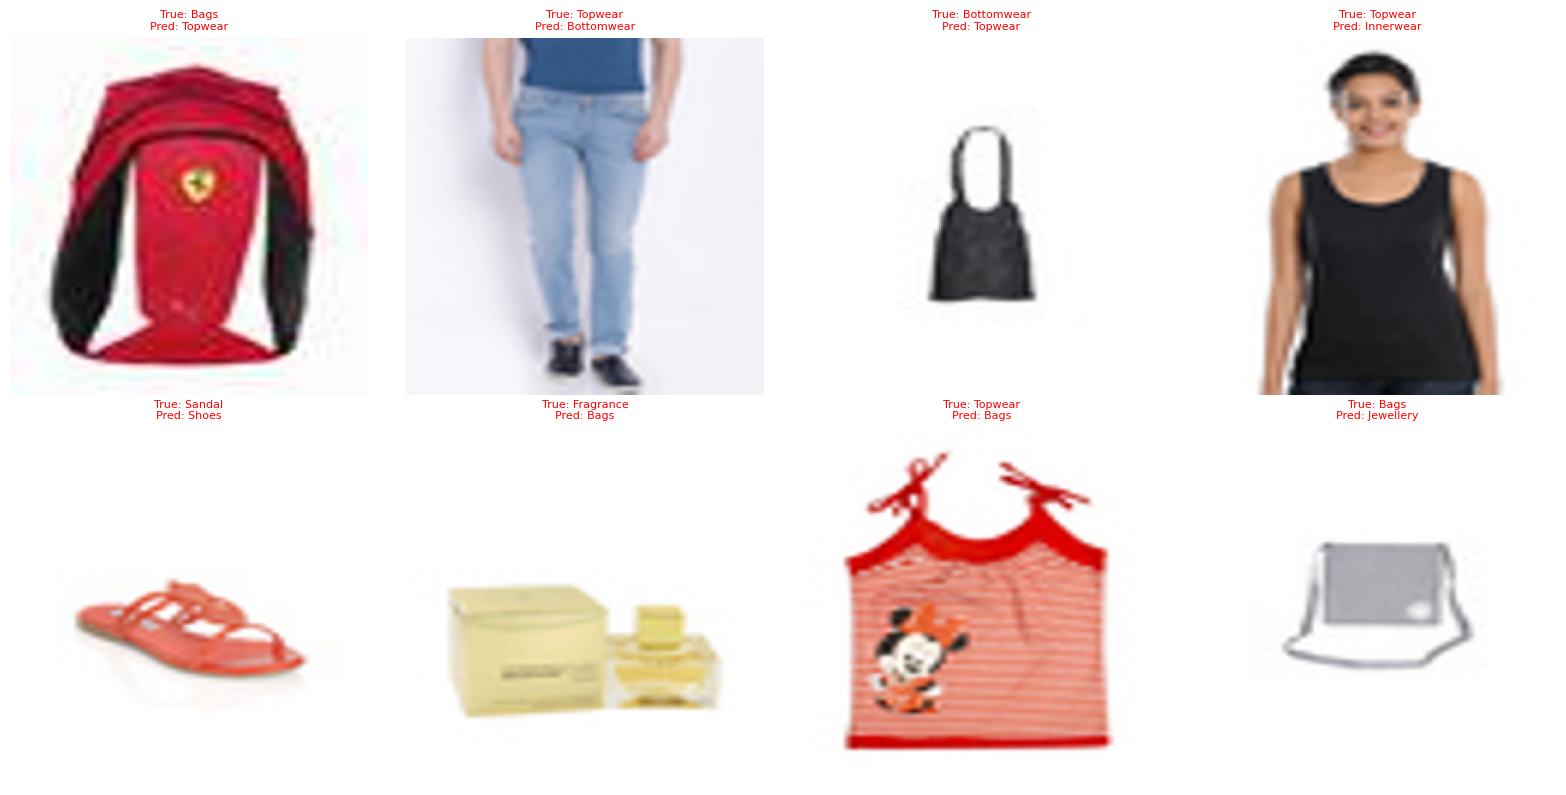

In [17]:
wrong_idx = np.where(custom_test_pred != y_test_true)[0]
print(f'Custom CNN misclassified: {len(wrong_idx)}/{len(y_test_true)} ({100 * len(wrong_idx) / len(y_test_true):.1f}%)')

wrong_true = [idx_to_class[y_test_true[i]] for i in wrong_idx]
wrong_pred = [idx_to_class[custom_test_pred[i]] for i in wrong_idx]
print('\nTop confusion pairs for Custom CNN:')
for (true_cls, pred_cls), count in Counter(zip(wrong_true, wrong_pred)).most_common(10):
    print(f'{true_cls:25s} -> {pred_cls:25s} {count:4d}')

# Show a few misclassified examples.
if len(wrong_idx) > 0:
    # Build arrays of test image paths in dataset order.
    test_paths = test_df['image_path'].values
    n_show = min(8, len(wrong_idx))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for plot_i in range(n_show):
        idx = wrong_idx[plot_i]
        img = Image.open(test_paths[idx]).convert('RGB').resize(IMG_SIZE)
        axes[plot_i].imshow(img)
        axes[plot_i].set_title(
            f'True: {idx_to_class[y_test_true[idx]]}\nPred: {idx_to_class[custom_test_pred[idx]]}',
            fontsize=8, color='red')
        axes[plot_i].axis('off')
    for plot_i in range(n_show, len(axes)):
        axes[plot_i].axis('off')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '13_custom_cnn_error_analysis.png', dpi=150)
    plt.show()


## 18. Save Models and Final Summary


In [18]:
custom_model.save('custom_cnn_final.keras')
tl_model.save('mobilenetv2_transfer_learning_final.keras')

print('Saved models:')
print('  custom_cnn_final.keras')
print('  mobilenetv2_transfer_learning_final.keras')
print(f'Figures saved in: {FIGURES_DIR.resolve()}')
print('\nFinal results:')
print(f'  Custom CNN Accuracy:       {custom_acc:.4f}')
print(f'  Custom CNN Weighted F1:    {custom_f1:.4f}')
print(f'  Custom CNN Micro-AUC:      {custom_micro_auc:.4f}')
print(f'  MobileNetV2 TL Accuracy:   {tl_acc:.4f}')
print(f'  MobileNetV2 TL Weighted F1:{tl_f1:.4f}')
print(f'  MobileNetV2 TL Micro-AUC:  {tl_micro_auc:.4f}')

if custom_acc >= TARGET_ACCURACY:
    print(f'\nCustom CNN reached the target accuracy of {TARGET_ACCURACY:.0%}.')
else:
    print(f'\nCustom CNN did not reach {TARGET_ACCURACY:.0%}. For a from-scratch CNN, try IMG_SIZE=(224,224), BATCH_SIZE=16, and more epochs. If the target is strict, transfer learning is usually the reliable path.')


Saved models:
  custom_cnn_final.keras
  mobilenetv2_transfer_learning_final.keras
Figures saved in: /kaggle/working/figures

Final results:
  Custom CNN Accuracy:       0.9841
  Custom CNN Weighted F1:    0.9841
  Custom CNN Micro-AUC:      0.9993
  MobileNetV2 TL Accuracy:   0.9879
  MobileNetV2 TL Weighted F1:0.9877
  MobileNetV2 TL Micro-AUC:  0.9992

Custom CNN reached the target accuracy of 90%.


In [19]:
import shutil
